# BANK CUSTOMER CHURN PREDICTION

10,000 bank customers, binary classification: will they stay or leave?  
Class split: ~80% stayed / ~20% churned.

---

## Notes on approach

**Data prep**  
Dropped `RowNumber` and `Surname` upfront (no predictive value). Verified that `CustomerId` is a proper unique key (it is). Built a few derived features before encoding.

**Encoding and scaling**  
`LabelEncoder` for Gender (already binary), one-hot for Geography with `drop_first=True` to avoid the dummy variable trap. `StandardScaler` after splitting - fitting it before the split would leak test information into the scaler.

**Train/test split - why stratified**  
80/20 with `stratify=y`. Without stratification the class ratio could end up slightly different in train and test by chance, which skews metric comparisons. No separate validation set: with 10K rows I didn't want to lose too much training data, so the ANN uses `validation_split=0.2` from within the training fold only (for early stopping - the test set is never touched during training).

**Models tested**  
Logistic Regression as a simple baseline, then Random Forest for non-linearity and feature importance, then ANN, and finally XGBoost and LightGBM which tend to be the strongest on tabular data. Added threshold tuning on XGBoost and SHAP for interpretability.

**Why not SMOTE**  
With 80/20 class ratio, reweighting the loss function is enough. SMOTE makes more sense for really severe imbalance like 1–2% minority - here it would just add synthetic noise without much benefit.

**Primary metric: Recall (not Accuracy)**  
A model that always predicts "stayed" gets 80% accuracy and catches zero churners. What matters is how many actual churners you identify. In practice, missing a customer who's about to leave (false negative) costs far more than sending an unnecessary retention offer (false positive). So Recall on the churned class is the primary metric, with AUC as secondary.

In [161]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report,
                              precision_recall_curve)
from xgboost import XGBClassifier
import lightgbm as lgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

os.makedirs('images', exist_ok=True)

print(f"TensorFlow {tf.__version__}  |  pandas {pd.__version__}")

TensorFlow 2.20.0  |  pandas 2.3.3


# IMPORT DATA

Despite the Kaggle description mentioning "employees", this is clearly bank customer data.

In [162]:
data = pd.read_csv('Churn_Modelling.csv')

In [163]:
data.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


# EDA

In [164]:
# drop RowNumber (just an index) and Surname (free text, no predictive value)
data = data.drop(columns=['Surname', 'RowNumber'])

Quick check: is CustomerId actually a unique key?

In [165]:
print(f"rows: {data.shape[0]}  |  unique CustomerIds: {data['CustomerId'].nunique()}")

rows: 10000  |  unique CustomerIds: 10000


Good, every row is a different customer.

In [166]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   CreditScore      10000 non-null  int64  
 2   Geography        10000 non-null  object 
 3   Gender           10000 non-null  object 
 4   Age              10000 non-null  int64  
 5   Tenure           10000 non-null  int64  
 6   Balance          10000 non-null  float64
 7   NumOfProducts    10000 non-null  int64  
 8   HasCrCard        10000 non-null  int64  
 9   IsActiveMember   10000 non-null  int64  
 10  EstimatedSalary  10000 non-null  float64
 11  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [167]:
data.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [168]:
print(data['Exited'].value_counts().to_string())
print()
print(data['Exited'].value_counts(normalize=True).mul(100).round(1).to_string())

Exited
0    7963
1    2037

Exited
0    79.6
1    20.4


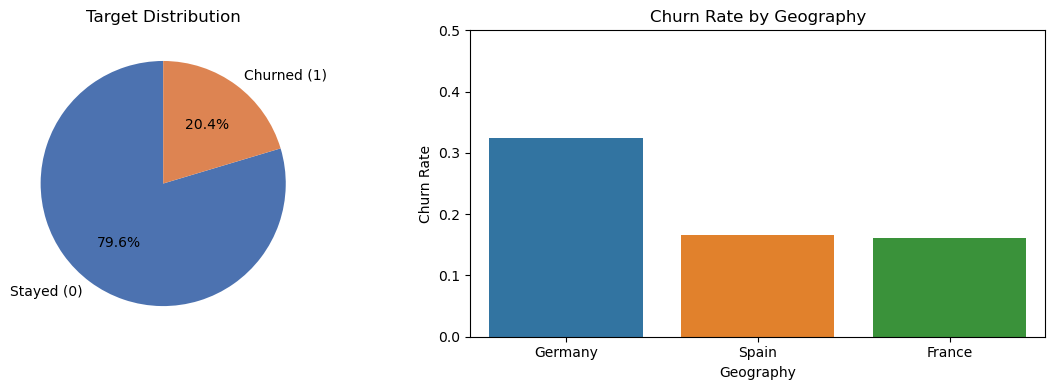

In [169]:
# class is moderately imbalanced (~20% churn)
labels = ['Stayed (0)', 'Churned (1)']
sizes  = data['Exited'].value_counts().values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[0].set_title('Target Distribution')

churn_rate_by_geo = data.groupby('Geography')['Exited'].mean().sort_values(ascending=False)
sns.barplot(x=churn_rate_by_geo.index, y=churn_rate_by_geo.values, ax=axes[1])
axes[1].set_title('Churn Rate by Geography')
axes[1].set_ylabel('Churn Rate')
axes[1].set_ylim(0, 0.5)

plt.tight_layout()
plt.show()

The class imbalance is moderate - 79.6% stayed vs 20.4% churned. Not extreme enough to be a major problem, but it needs to be factored into the models. Germany already stands out with a churn rate close to 32%, roughly double France and Spain.

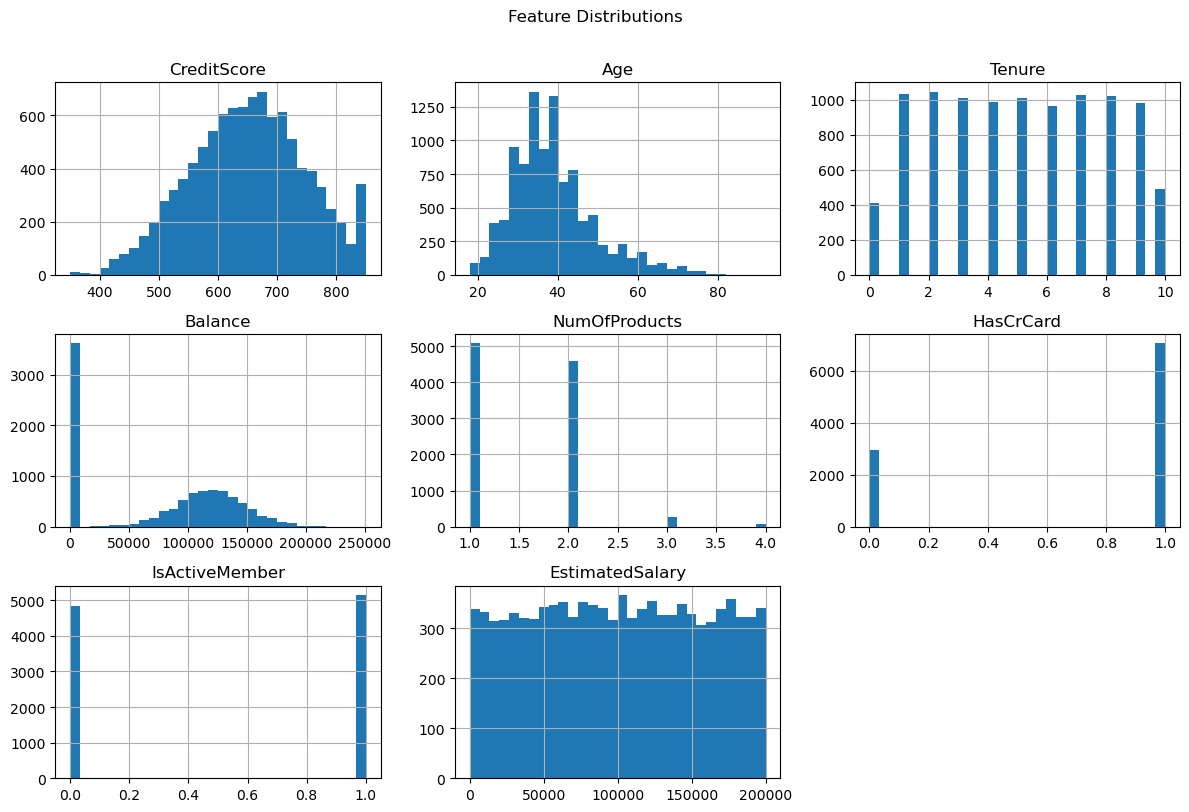

In [170]:
# Distribution of all numerical features (RowNumber already dropped, CustomerId excluded)
data.drop(columns=['CustomerId', 'Exited']).hist(figsize=(12, 8), bins=30)
plt.suptitle('Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

Balance has a large spike at zero - a significant chunk of customers have no money in the account at all. Age looks roughly normal. Tenure is spread almost uniformly across years, which is a bit unusual.

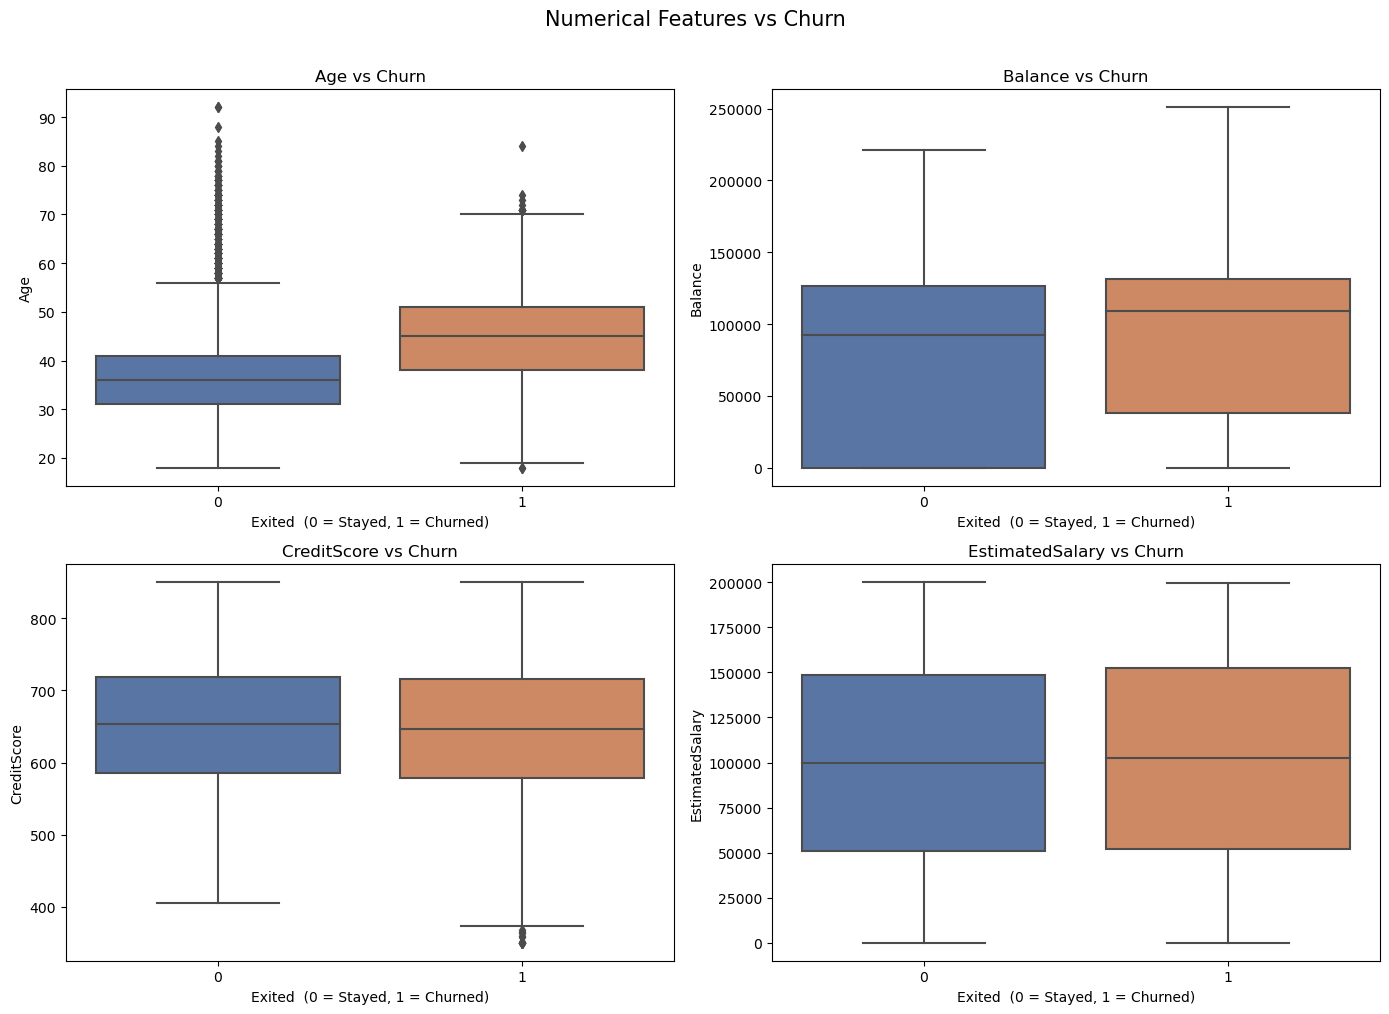

In [171]:
# do churners look different on the numerical features?
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
palette = ['#4C72B0', '#DD8452']

for ax, feat in zip(axes.flatten(), ['Age', 'Balance', 'CreditScore', 'EstimatedSalary']):
    sns.boxplot(data=data, x='Exited', y=feat, palette=palette, ax=ax)
    ax.set_title(f'{feat} vs Churn', fontsize=12)
    ax.set_xlabel('Exited  (0 = Stayed, 1 = Churned)')

plt.suptitle('Numerical Features vs Churn', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Age is the clearest separator: churners are noticeably older on average. Balance is counterintuitive - churners actually have a *higher* median balance, which is not what you'd expect. CreditScore and EstimatedSalary barely differ between the two groups.

In [172]:
pd.crosstab(
    data['Geography'],
    data['Exited'],
    normalize='index'
)

Exited,0,1
Geography,,
France,0.838452,0.161548
Germany,0.675568,0.324432
Spain,0.833266,0.166734


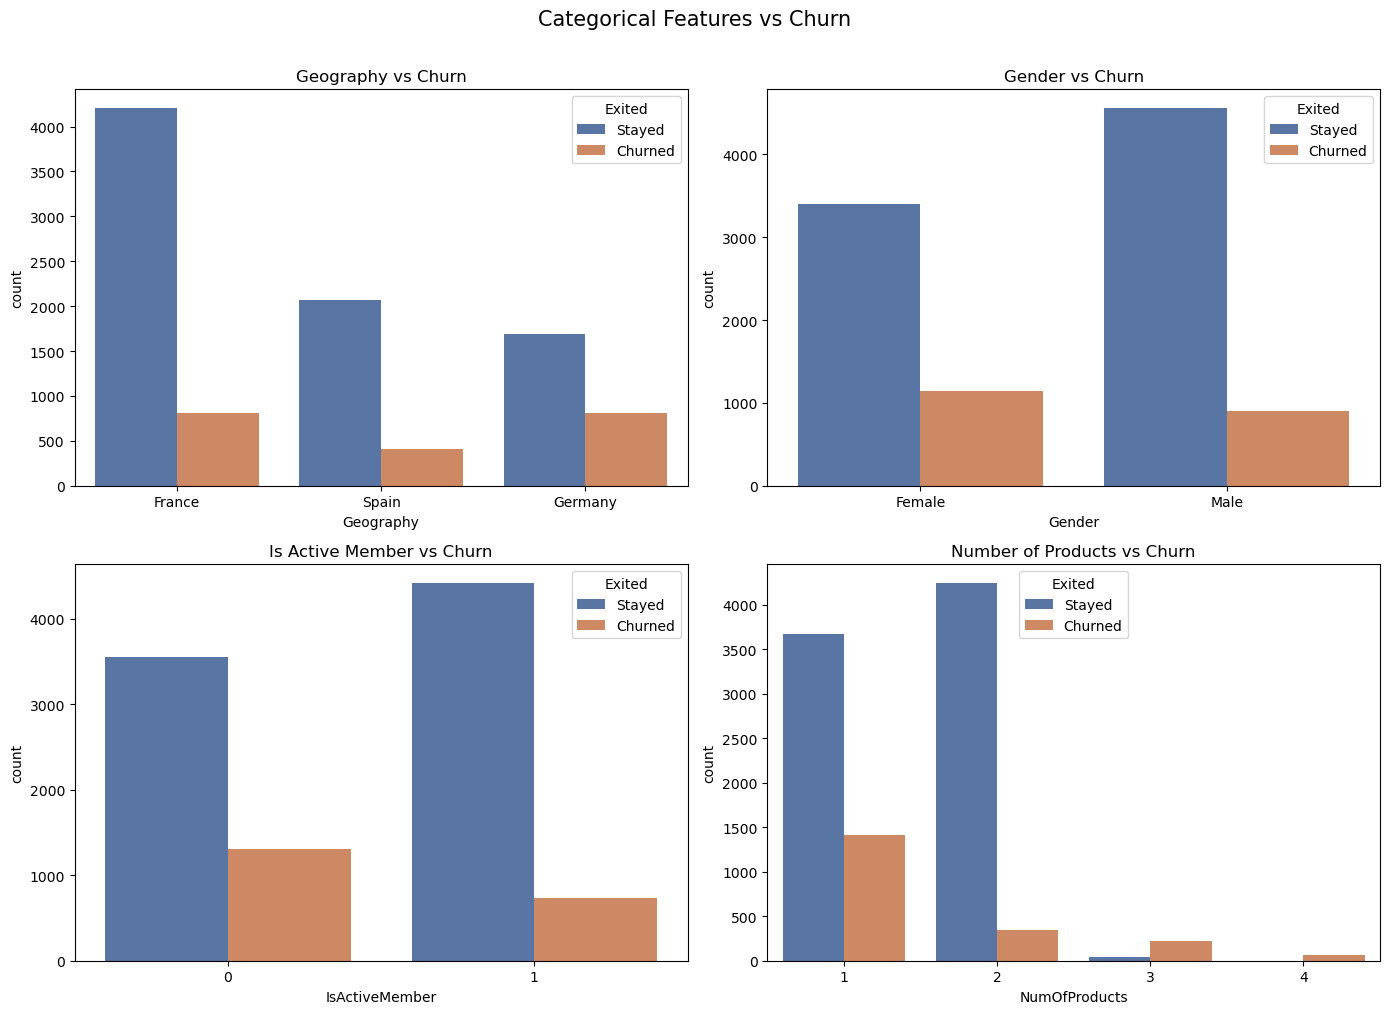

In [173]:
# which segments churn more?
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
palette = ['#4C72B0', '#DD8452']

categorical_features = [
    ('Geography',      'Geography'),
    ('Gender',         'Gender'),
    ('IsActiveMember', 'Is Active Member'),
    ('NumOfProducts',  'Number of Products'),
]

for ax, (feat, title) in zip(axes.flatten(), categorical_features):
    sns.countplot(data=data, x=feat, hue='Exited', palette=palette, ax=ax)
    ax.set_title(f'{title} vs Churn', fontsize=12)
    ax.legend(title='Exited', labels=['Stayed', 'Churned'])

plt.suptitle('Categorical Features vs Churn', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Germany confirms what the bar chart showed. Inactive members churn at roughly twice the rate of active ones - probably the most actionable signal here from a business standpoint. The NumOfProducts result is interesting: 1 or 2 products, churn is low; 3 or 4 products, churn shoots up. Possibly over-sold customers who are not using what they have.

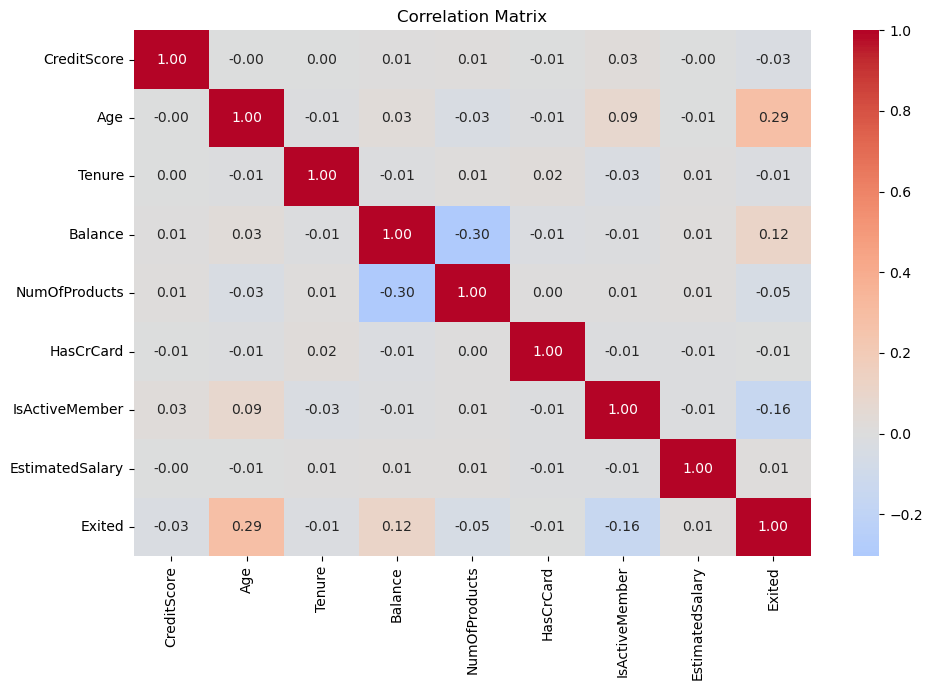

In [174]:
# correlation between numerical features (excluding CustomerID)
corr = data.drop(columns=['CustomerId']).select_dtypes('number').corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

No strong linear correlations with the target. Age has the highest (~0.29). The relationships are mostly non-linear, which is partly why tree-based models tend to outperform logistic regression on this kind of data.

# DATA CLEANING

In [175]:
print("missing values:")
print(data.isnull().sum().to_string())
print(f"\ntotal missing: {data.isnull().sum().sum()}")

print(f"\nduplicate rows: {data.duplicated().sum()}")

print("\ndtypes:")
print(data.dtypes.to_string())

missing values:
CustomerId         0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0

total missing: 0

duplicate rows: 0

dtypes:
CustomerId           int64
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64


No missing values, no duplicates. Clean dataset, one less thing to deal with.

# FEATURE ENGINEERING

In [176]:
data['BalanceZero'] = (data['Balance'] == 0).astype(int)           # flag for dormant accounts
data['BalanceSalaryRatio'] = data['Balance'] / (data['EstimatedSalary'] + 1)  # +1 avoids div by zero
data['Age_Tenure_Ratio'] = data['Age'] / (data['Tenure'] + 1)     # older + short tenure = at risk

print(data[['BalanceZero', 'BalanceSalaryRatio', 'Age_Tenure_Ratio']].describe().round(3))
print(f"\nchurn rate - zero balance:     {data[data['BalanceZero']==1]['Exited'].mean():.2%}")
print(f"churn rate - non-zero balance: {data[data['BalanceZero']==0]['Exited'].mean():.2%}")

       BalanceZero  BalanceSalaryRatio  Age_Tenure_Ratio
count    10000.000           10000.000         10000.000
mean         0.362               3.790             9.456
std          0.481             100.056             8.474
min          0.000               0.000             1.636
25%          0.000               0.000             4.400
50%          0.000               0.747             6.429
75%          1.000               1.514            11.000
max          1.000            9770.883            79.000

churn rate - zero balance:     13.82%
churn rate - non-zero balance: 24.08%


The BalanceZero flag looks useful already - customers with zero balance churn at a noticeably higher rate. The other two features are more speculative but worth keeping and letting the models decide.

# PREPROCESSING

In [177]:
# encode gender as 0/1
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

# one-hot geography, drop_first to avoid the dummy variable trap
# France becomes the reference category (it gets dropped)
data = pd.get_dummies(data, columns=['Geography'], drop_first=True)

data = data.drop(columns=['CustomerId'])  # just an ID, no predictive value

X = data.drop(columns=['Exited'])
y = data['Exited']

print(f"shape: {X.shape}")
print(f"\nfeatures: {list(X.columns)}")
print(f"\nchurn rate: {y.mean():.2%}  ({y.sum()} out of {len(y)})")

shape: (10000, 14)

features: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceZero', 'BalanceSalaryRatio', 'Age_Tenure_Ratio', 'Geography_Germany', 'Geography_Spain']

churn rate: 20.37%  (2037 out of 10000)


# TRAIN/TEST SPLIT

In [178]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps the 80/20 class ratio balanced in both splits
)

# fit scaler on train only - never fit on the full dataset before splitting
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"train: {X_train_sc.shape[0]}  |  test: {X_test_sc.shape[0]}")
print(f"churn rate - train: {y_train.mean():.2%}  |  test: {y_test.mean():.2%}")

train: 8000  |  test: 2000
churn rate - train: 20.38%  |  test: 20.35%


# MODEL TRAINING

## Baseline - Logistic Regression

Simple and interpretable. Useful to set a performance floor - if something fancier can't beat it, it's not worth the added complexity.

In [179]:
# class_weight='balanced' increases the penalty for misclassifying the minority class
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]

print("Logistic Regression")
print(f"accuracy: {accuracy_score(y_test, y_pred_lr):.4f}  |  auc: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['Stayed', 'Churned']))

Logistic Regression
accuracy: 0.7135  |  auc: 0.7768
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1593
     Churned       0.39      0.71      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



Decent baseline. AUC around 0.78 sets the floor to beat. Recall on churners is reasonable for a linear model, though precision is quite low - it flags a lot of false positives.

## Random Forest

Doesn't need scaled features, handles non-linearity well, and gives you feature importances for free.

Random Forest
accuracy: 0.8665  |  auc: 0.8519
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
     Churned       0.81      0.45      0.58       407

    accuracy                           0.87      2000
   macro avg       0.84      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



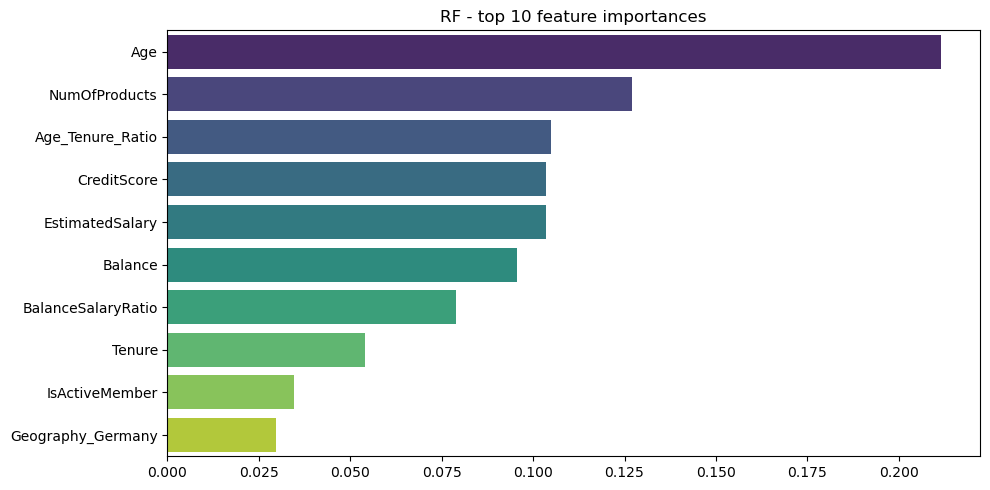

In [180]:
# tree models don't need scaled features
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print(f"accuracy: {accuracy_score(y_test, y_pred_rf):.4f}  |  auc: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Churned']))

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10], palette='viridis')
plt.title('RF - top 10 feature importances')
plt.tight_layout()
plt.savefig('images/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

This is the most instructive result in the notebook. 86% accuracy and 81% precision look great on paper - but only 44.7% recall means it's missing more than half the customers who actually churned. The feature importances confirm Age as the dominant predictor, followed by Balance and NumOfProducts.

## Artificial Neural Network

3 hidden layers (64 → 32 → 16), BatchNorm to stabilize training, Dropout for regularization.  
Gave 4x weight to churners since they're underrepresented - tuned by hand, not optimal but works.

Model: "ANN_Churn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4917 - loss: 1.2603 - val_accuracy: 0.7875 - val_loss: 0.5186
Epoch 2/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6564 - loss: 1.0214 - val_accuracy: 0.7575 - val_loss: 0.5112
Epoch 3/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6874 - loss: 0.9573 - val_accuracy: 0.7663 - val_loss: 0.4934
Epoch 4/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7219 - loss: 0.9275 - val_accuracy: 0.7725 - val_loss: 0.4833
Epoch 5/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7260 - loss: 0.8852 - val_accuracy: 0.7631 - val_loss: 0.4771
Epoch 6/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7225 - loss: 0.8780 - val_accuracy: 0.7694 - val_loss: 0.4723
Epoch 7/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7415 - loss: 0.8304 - val_accuracy: 0.7781 - val_loss: 0.4595
Epoch 8/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7430 - loss: 0.8522 - val_acc

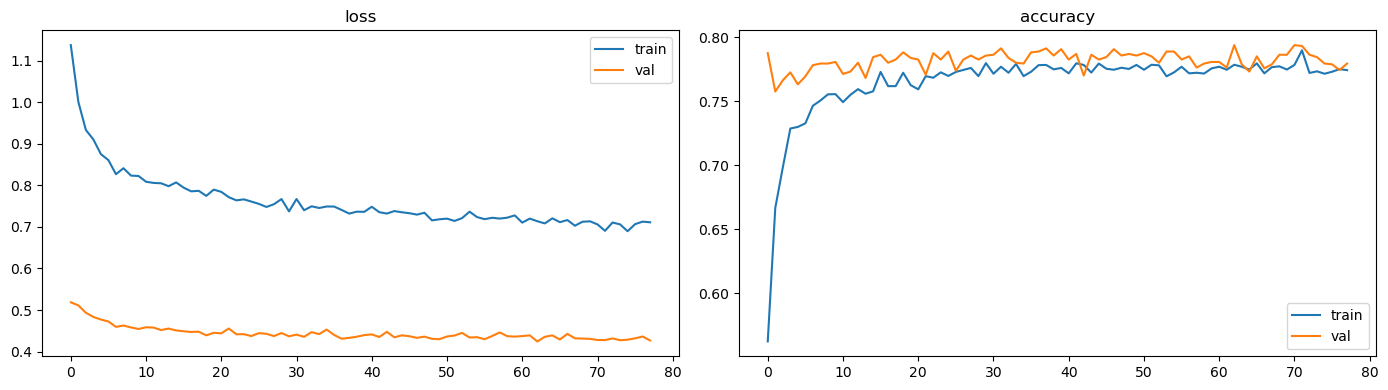

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
ANN
accuracy: 0.7850  |  auc: 0.8605
              precision    recall  f1-score   support

      Stayed       0.93      0.79      0.85      1593
     Churned       0.48      0.76      0.59       407

    accuracy                           0.79      2000
   macro avg       0.71      0.78      0.72      2000
weighted avg       0.84      0.79      0.80      2000



In [181]:
tf.random.set_seed(42)

# 64 → 32 → 16 → 1 (sigmoid output = churn probability)
ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_sc.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
], name='ANN_Churn')

ann.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann.summary()

# stop if val_loss doesn't improve for 15 epochs, then restore best weights
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)

class_weights = {0: 1, 1: 4}  # 4x weight on churners

history = ann.fit(
    X_train_sc, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'],         label='train')
axes[0].plot(history.history['val_loss'],     label='val')
axes[0].set_title('loss')
axes[0].legend()
axes[1].plot(history.history['accuracy'],     label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

y_prob_ann = ann.predict(X_test_sc).ravel()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

print("ANN")
print(f"accuracy: {accuracy_score(y_test, y_pred_ann):.4f}  |  auc: {roc_auc_score(y_test, y_prob_ann):.4f}")
print(classification_report(y_test, y_pred_ann, target_names=['Stayed', 'Churned']))

Best recall among the baseline models (~77%). The 4x class weight pushed it toward catching more churners at the cost of some precision. AUC 0.86 is solid. Training curves look stable - no obvious overfitting, early stopping kicked in well before the 150 epoch limit.

## XGBoost

Generally the strongest model on tabular data. `scale_pos_weight` is XGBoost's native way to deal with class imbalance (neg/pos sample ratio).

In [182]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # neg/pos ratio

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_sc, y_train)

y_pred_xgb = xgb.predict(X_test_sc)
y_prob_xgb = xgb.predict_proba(X_test_sc)[:, 1]

print("XGBoost")
print(f"accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}  |  auc: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=['Stayed', 'Churned']))

XGBoost
accuracy: 0.8070  |  auc: 0.8661
              precision    recall  f1-score   support

      Stayed       0.93      0.82      0.87      1593
     Churned       0.52      0.74      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



AUC 0.866 and recall 0.74. Similar recall to the ANN but with better precision. XGBoost on tabular data tends to perform well and this confirms it.

## LightGBM

Similar to XGBoost but usually trains faster. Uses leaf-wise splits instead of level-wise.

In [183]:
lgbm = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
lgbm.fit(X_train_sc, y_train)

y_pred_lgbm = lgbm.predict(X_test_sc)
y_prob_lgbm = lgbm.predict_proba(X_test_sc)[:, 1]

print("LightGBM")
print(f"accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}  |  auc: {roc_auc_score(y_test, y_prob_lgbm):.4f}")
print(classification_report(y_test, y_pred_lgbm, target_names=['Stayed', 'Churned']))

LightGBM
accuracy: 0.8075  |  auc: 0.8650
              precision    recall  f1-score   support

      Stayed       0.92      0.83      0.87      1593
     Churned       0.52      0.73      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



Essentially identical to XGBoost - AUC 0.865 vs 0.866, recall 0.73 vs 0.74. At this dataset size the two are interchangeable. LightGBM was faster to train though.

## Threshold Tuning

Models output a probability, not directly a label. The default 0.5 cutoff isn't always the best choice - here I'm looking for the lowest threshold that still keeps precision above 0.45.

default (0.50):  recall=0.7396  precision=0.5181  f1=0.6093
tuned   (0.39):  recall=0.8280  precision=0.4505  f1=0.5835

              precision    recall  f1-score   support

      Stayed       0.94      0.74      0.83      1593
     Churned       0.45      0.83      0.58       407

    accuracy                           0.76      2000
   macro avg       0.70      0.79      0.71      2000
weighted avg       0.84      0.76      0.78      2000



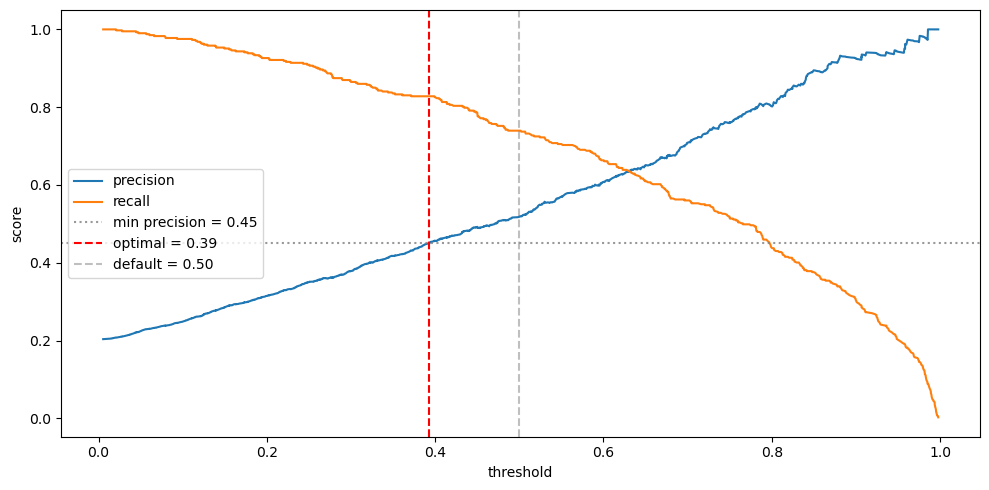

In [184]:
precisions_c, recalls_c, thresholds_c = precision_recall_curve(y_test, y_prob_xgb)

# find the lowest threshold where precision is still >= 0.45
# (optimizing for F1 here would actually raise the threshold and reduce recall)
MIN_PRECISION = 0.45
valid_mask    = precisions_c[:-1] >= MIN_PRECISION
best_threshold = float(thresholds_c[(recalls_c[:-1] * valid_mask).argmax()])

y_pred_xgb_tuned = (y_prob_xgb >= best_threshold).astype(int)

print(f"default (0.50):  recall={recall_score(y_test, y_pred_xgb):.4f}  "
      f"precision={precision_score(y_test, y_pred_xgb):.4f}  f1={f1_score(y_test, y_pred_xgb):.4f}")
print(f"tuned   ({best_threshold:.2f}):  recall={recall_score(y_test, y_pred_xgb_tuned):.4f}  "
      f"precision={precision_score(y_test, y_pred_xgb_tuned):.4f}  f1={f1_score(y_test, y_pred_xgb_tuned):.4f}")
print()
print(classification_report(y_test, y_pred_xgb_tuned, target_names=['Stayed', 'Churned']))

plt.figure(figsize=(10, 5))
plt.plot(thresholds_c, precisions_c[:-1], label='precision')
plt.plot(thresholds_c, recalls_c[:-1],    label='recall')
plt.axhline(MIN_PRECISION, color='grey',  linestyle=':', alpha=0.8,
            label=f'min precision = {MIN_PRECISION}')
plt.axvline(best_threshold, color='r',    linestyle='--', label=f'optimal = {best_threshold:.2f}')
plt.axvline(0.5,            color='grey', linestyle='--', alpha=0.5, label='default = 0.50')
plt.xlabel('threshold')
plt.ylabel('score')
plt.legend()
plt.tight_layout()
plt.savefig('images/threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

Moving the threshold down from 0.5 pushed recall up to 0.83 while keeping precision just above 0.45. That's a meaningful gain with no retraining at all. The chart makes clear that 0.5 was not the right cutoff here - there was a lot of recall being left on the table.

## Shap

Feature importances tell you *what* the model uses. SHAP tells you *how* - direction and magnitude for each prediction, not just globally.

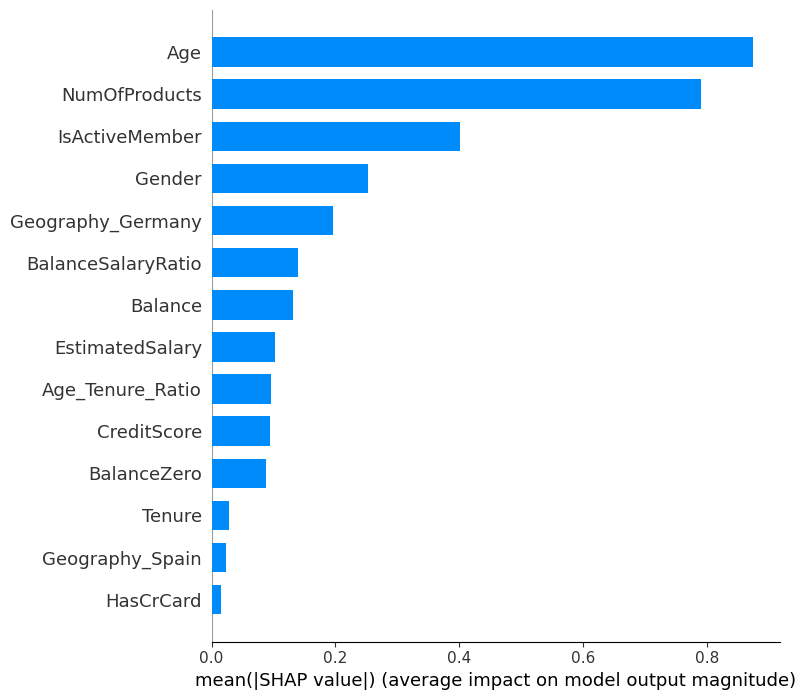

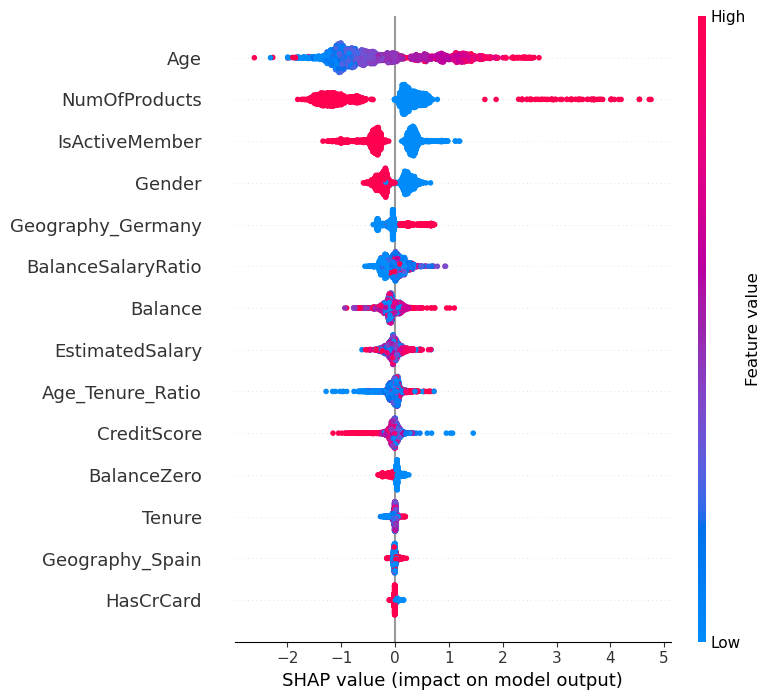

In [185]:
# TreeExplainer is the fast path for tree-based models
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_sc)

X_test_df = pd.DataFrame(X_test_sc, columns=X.columns)

# global importance: mean |SHAP| across all test samples
plt.figure()
shap.summary_plot(shap_values, X_test_df, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('images/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# beeswarm: each dot is one sample
# red = high feature value, blue = low; right = pushes toward churn
plt.figure()
shap.summary_plot(shap_values, X_test_df, show=False)
plt.tight_layout()
plt.savefig('images/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

Age dominates - high values push strongly toward churn. NumOfProducts is second, and the beeswarm makes the non-linear effect visible: high values correlate with churn, low values with staying. Geography_Germany shows up as expected. Balance has mixed direction, which explains why the linear correlation in the heatmap was weak - the effect is non-linear.

# MODEL EVALUATION & COMPARISON

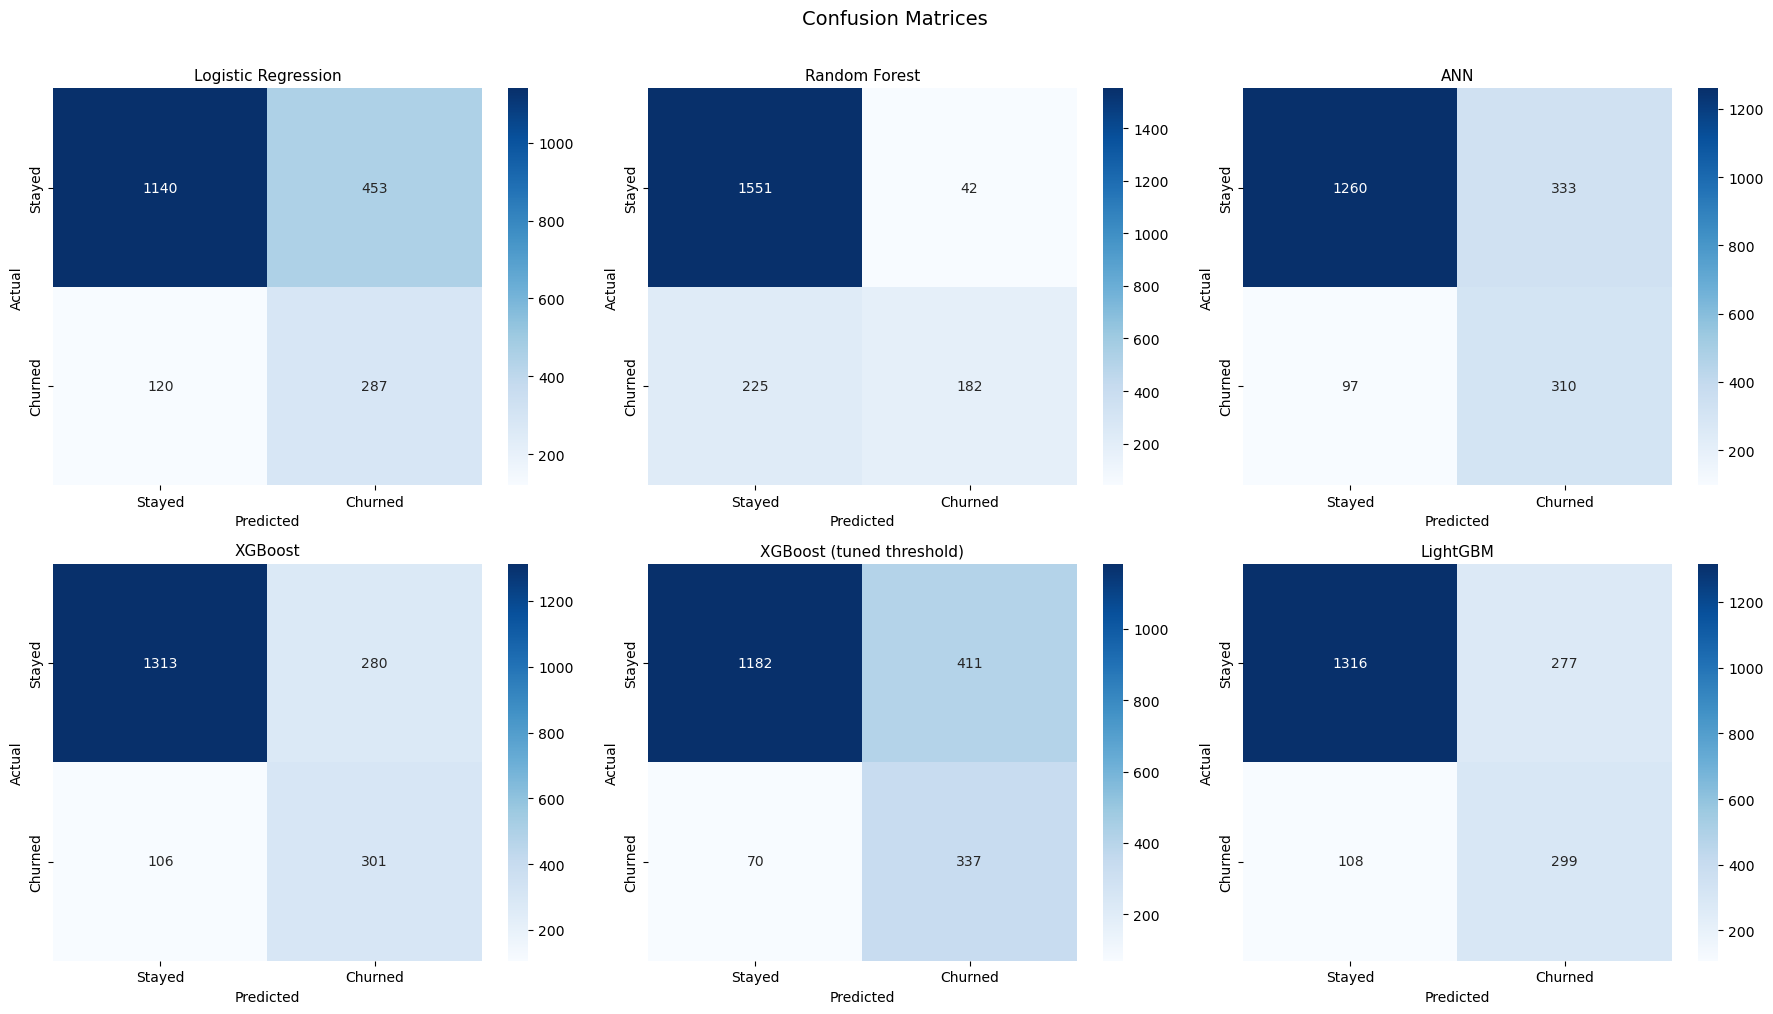

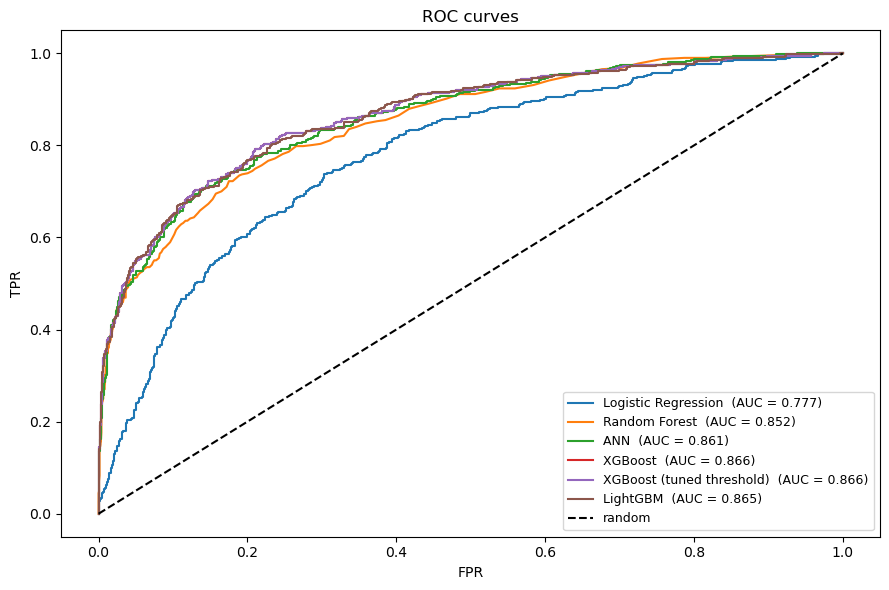

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
XGBoost (tuned threshold),0.7595,0.4505,0.8280,0.5835,0.8661
ANN,0.7850,0.4821,0.7617,0.5905,0.8605
XGBoost,0.8070,0.5181,0.7396,0.6093,0.8661
LightGBM,0.8075,0.5191,0.7346,0.6083,0.8650
Logistic Regression,0.7135,0.3878,0.7052,0.5004,0.7768
Random Forest,0.8665,0.8125,0.4472,0.5769,0.8519


In [186]:
all_models = [
    ('Logistic Regression',       y_pred_lr,        y_prob_lr),
    ('Random Forest',             y_pred_rf,        y_prob_rf),
    ('ANN',                       y_pred_ann,       y_prob_ann),
    ('XGBoost',                   y_pred_xgb,       y_prob_xgb),
    ('XGBoost (tuned threshold)', y_pred_xgb_tuned, y_prob_xgb),
    ('LightGBM',                  y_pred_lgbm,      y_prob_lgbm),
]

# confusion matrices for all 6 models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (name, y_pred, _) in zip(axes.flatten(), all_models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Churned'],
                yticklabels=['Stayed', 'Churned'])
    ax.set_title(name, fontsize=11)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curves
plt.figure(figsize=(9, 6))
for name, _, y_prob in all_models:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {roc_auc_score(y_test, y_prob):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='random')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curves')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('images/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# summary table, sorted by recall
results = []
for name, y_pred, y_prob in all_models:
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred),    4),
        'F1'       : round(f1_score(y_test, y_pred),        4),
        'AUC'      : round(roc_auc_score(y_test, y_prob),   4),
    })

final_df = pd.DataFrame(results).set_index('Model')
display(final_df.sort_values('Recall', ascending=False))

# CONCLUSIONS

## What the EDA showed
- Age is the strongest single predictor - churners tend to be significantly older
- Germany has a much higher churn rate than France and Spain (visible in the crosstab)
- Inactive members churn roughly twice as often as active ones
- Customers with 2+ products have surprisingly high churn - possibly over-sold
- Zero-balance customers are a distinct at-risk group

## Model results
Random Forest had the best accuracy (86.7%) and precision (81.3%) but only caught 44.7% of churners. That's the worst result for the actual problem. XGBoost with threshold tuning reached 82.8% recall with AUC 0.866 - best overall for catching churners.

The gap between accuracy and recall here is a good reminder that accuracy is basically useless as a standalone metric when classes are unbalanced.